In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [28]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        self.weight      = nn.Parameter(torch.empty(out_features, in_features))
        self.bias        = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        bound = 1.0 / np.sqrt(in_features)
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        gates          = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

In [29]:
class SelfPruningNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(3072, 1024)
        self.fc2 = PrunableLinear(1024, 512)
        self.fc3 = PrunableLinear(512,  256)
        self.fc4 = PrunableLinear(256,  10)
        self.bn1  = nn.BatchNorm1d(1024)
        self.bn2  = nn.BatchNorm1d(512)
        self.bn3  = nn.BatchNorm1d(256)
        self.drop = nn.Dropout(0.3)

    def forward(self, x):
        x = self.flatten(x)
        x = self.drop(F.relu(self.bn1(self.fc1(x))))
        x = self.drop(F.relu(self.bn2(self.fc2(x))))
        x = self.drop(F.relu(self.bn3(self.fc3(x))))
        return self.fc4(x)

    def sparsity_loss(self):
        all_gates = torch.cat([
            torch.sigmoid(m.gate_scores).flatten()
            for m in self.modules()
            if isinstance(m, PrunableLinear)
        ])
        return all_gates.mean()

    def sparsity_level(self):
        with torch.no_grad():
            all_gates = torch.cat([
                torch.sigmoid(m.gate_scores).flatten()
                for m in self.modules()
                if isinstance(m, PrunableLinear)
            ])
        return (all_gates < 0.5).float().mean().item() * 100

    def all_gate_values(self):
        with torch.no_grad():
            all_gates = torch.cat([
                torch.sigmoid(m.gate_scores).flatten()
                for m in self.modules()
                if isinstance(m, PrunableLinear)
            ])
        return all_gates.cpu().numpy()

In [30]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

train_set = torchvision.datasets.CIFAR10('./data', train=True,
                                          download=True, transform=train_transform)
test_set  = torchvision.datasets.CIFAR10('./data', train=False,
                                          download=True, transform=test_transform)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True,
                          num_workers=0)   # ← was 2, Colab multiprocessing crashes with >0
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False,
                          num_workers=0)   # ← was 2

print(f"Train: {len(train_set):,} samples | Test: {len(test_set):,} samples")

Train: 50,000 samples | Test: 10,000 samples


In [31]:
@torch.no_grad()
def evaluate(model):
    model.eval()
    correct = total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        correct += (model(images).argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return correct / total * 100


def train(lam, epochs=50, warmup_epochs=10):
    model = SelfPruningNet().to(device)


    gate_params   = [p for n, p in model.named_parameters() if 'gate_scores' in n]
    weight_params = [p for n, p in model.named_parameters() if 'gate_scores' not in n]

    optimizer = optim.Adam([
        {'params': weight_params, 'lr': 1e-3},
        {'params': gate_params,   'lr': 1e-1},
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    print(f"\n── λ = {lam}  |  warmup = {warmup_epochs} epochs ──────────────")

    for epoch in range(1, epochs + 1):
        effective_lam = 0.0 if epoch <= warmup_epochs else lam

        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            logits     = model(images)
            cls_loss   = F.cross_entropy(logits, labels)
            sp_loss    = model.sparsity_loss()
            total_loss = cls_loss + effective_lam * sp_loss

            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        scheduler.step()

        if epoch % 10 == 0 or epoch == 1:
            acc      = evaluate(model)
            sparsity = model.sparsity_level()
            phase    = "warmup" if epoch <= warmup_epochs else "pruning"
            print(f"  Epoch {epoch:02d}/{epochs} | {phase} | "
                  f"TestAcc: {acc:.2f}% | Sparsity: {sparsity:.2f}%")

    return model, evaluate(model), model.sparsity_level()

In [32]:
LAMBDAS    = [0.1, 0.5, 2.0]
labels_map = {0.1: 'Low', 0.5: 'Medium', 2.0: 'High'}

results = {}
for lam in LAMBDAS:
    model, acc, sparsity = train(lam)
    results[lam] = {'model': model, 'acc': acc, 'sparsity': sparsity}

print("\nLambda        | Test Accuracy (%) | Sparsity Level (%)")
print("--------------|-------------------|--------------------")
for lam, r in results.items():
    print(f"{lam} ({labels_map[lam]:<6}) | {r['acc']:>17.2f} | {r['sparsity']:>18.2f}")


── λ = 0.1  |  warmup = 10 epochs ──────────────
  Epoch 01/50 | warmup | TestAcc: 41.95% | Sparsity: 60.32%
  Epoch 10/50 | warmup | TestAcc: 54.12% | Sparsity: 69.37%
  Epoch 20/50 | pruning | TestAcc: 57.84% | Sparsity: 76.06%
  Epoch 30/50 | pruning | TestAcc: 59.47% | Sparsity: 77.57%
  Epoch 40/50 | pruning | TestAcc: 60.48% | Sparsity: 77.90%
  Epoch 50/50 | pruning | TestAcc: 60.85% | Sparsity: 77.93%

── λ = 0.5  |  warmup = 10 epochs ──────────────
  Epoch 01/50 | warmup | TestAcc: 42.37% | Sparsity: 60.44%
  Epoch 10/50 | warmup | TestAcc: 54.74% | Sparsity: 69.30%
  Epoch 20/50 | pruning | TestAcc: 57.43% | Sparsity: 82.39%
  Epoch 30/50 | pruning | TestAcc: 59.26% | Sparsity: 84.39%
  Epoch 40/50 | pruning | TestAcc: 60.17% | Sparsity: 84.93%
  Epoch 50/50 | pruning | TestAcc: 60.31% | Sparsity: 84.99%

── λ = 2.0  |  warmup = 10 epochs ──────────────
  Epoch 01/50 | warmup | TestAcc: 41.10% | Sparsity: 60.32%
  Epoch 10/50 | warmup | TestAcc: 54.34% | Sparsity: 69.28%
  

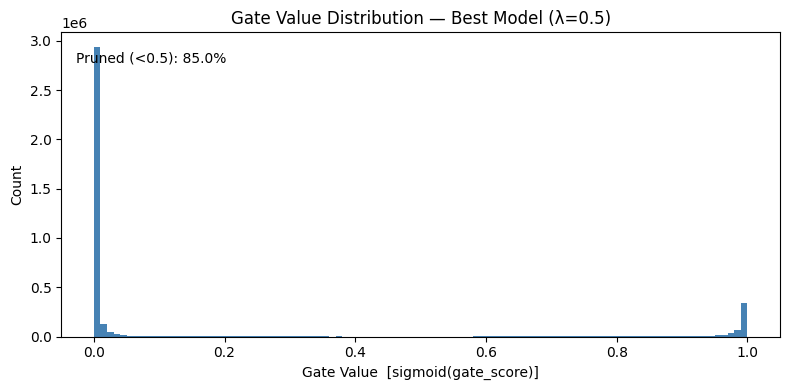

In [33]:
best_lam  = 0.5
gate_vals = results[best_lam]['model'].all_gate_values()

plt.figure(figsize=(8, 4))
plt.hist(gate_vals, bins=100, color='steelblue', edgecolor='none')
plt.title(f"Gate Value Distribution — Best Model (λ={best_lam})")
plt.xlabel("Gate Value  [sigmoid(gate_score)]")
plt.ylabel("Count")
plt.annotate(f"Pruned (<0.5): {(gate_vals < 0.5).mean()*100:.1f}%",
             xy=(0.02, 0.90), xycoords='axes fraction', fontsize=10)
plt.tight_layout()
plt.savefig("gate_distribution.png", dpi=150)
plt.show()